# Analyse et Visualisation des Données Climatiques

#### L’analyse commence par l’importation des bibliothèques Python essentielles. pandas est utilisé pour la manipulation des données, tandis que matplotlib.pyplot et seaborn servent à créer des visualisations claires et informatives pour l’analyse.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Deux URLs sont définies pour accéder directement aux jeux de données au format CSV depuis Google Sheets. Ces liens permettent de charger les données de température et d’émissions de CO₂ dans l’environnement Python pour l’analyse.

In [51]:
url_temp = 'https://docs.google.com/spreadsheets/d/1MT7pe2DbL_5fI6Sg5fPnn2oxgCqzyBnNpa4X1HsxhJg/export?format=csv'
url_co2 = 'https://docs.google.com/spreadsheets/d/1NYQ1eJsi4ncE__XO5fb6r026bXYNc4LVajKO4OYqpk0/export?format=csv'

#### Les jeux de données sont chargés dans des DataFrames pandas à l’aide de la fonction read_csv(). Les données de température et de CO₂ sont ainsi importées et prêtes à être manipulées et analysées.

In [52]:
temp = pd.read_csv(url_temp)
co2 = pd.read_csv(url_co2)

#### La méthode head() est utilisée pour afficher les cinq premières lignes du jeu de données de température. Cela permet de vérifier rapidement la structure des données, les noms des colonnes et le contenu général.

In [53]:
temp.head()

,Year,Land,Land and Ocean,N Hem,S Hem,Band 1,Band 2,Band 3
0,1880,-0.41,-0.20,-0.34,-0.05,NaN,NaN,NaN
1,1881,-0.39,-0.11,-0.20,-0.02,NaN,NaN,NaN
2,1882,-0.30,-0.09,-0.18,-0.01,NaN,NaN,NaN
3,1883,-0.32,-0.20,-0.31,-0.08,NaN,NaN,NaN
4,1884,-0.60,-0.27,-0.42,-0.12,NaN,NaN,NaN


#### Cette méthode compte le nombre de valeurs manquantes (NaN) dans chaque colonne du DataFrame temp.

In [54]:
temp.isna().sum()

Year               0
Land               0
Land and Ocean     0
N Hem              0
S Hem              0
Band 1            20
Band 2            20
Band 3            20
dtype: int64

#### duplicated() methode permet de verifier si le dataframe contient des doublons et de compter leur nombre a l'aide de la methode sum().

In [55]:
temp.duplicated().sum()

np.int64(0)

#### La méthode info() fournit un résumé du jeu de données, incluant le nombre de lignes, les noms des colonnes et les types de données. Cela permet de mieux comprendre la structure et la qualité des données.

In [56]:
temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            136 non-null    int64  
 1   Land            136 non-null    float64
 2   Land and Ocean  136 non-null    float64
 3   N Hem           136 non-null    float64
 4   S Hem           136 non-null    float64
 5   Band 1          116 non-null    float64
 6   Band 2          116 non-null    float64
 7   Band 3          116 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 8.6 KB


#### Cette commande supprime toutes les lignes contenant au moins une valeur manquante (NaN) du DataFrame temp, puis stocke le résultat nettoyé dans le même DataFrame temp.

In [57]:
temp = temp.dropna()

In [58]:
temp.isna().sum()

Year              0
Land              0
Land and Ocean    0
N Hem             0
S Hem             0
Band 1            0
Band 2            0
Band 3            0
dtype: int64

In [59]:
temp.head()

,Year,Land,Land and Ocean,N Hem,S Hem,Band 1,Band 2,Band 3
20,1900,-0.15,-0.09,-0.04,-0.14,-0.13,0.14,-0.34
21,1901,-0.14,-0.14,-0.08,-0.21,-0.11,-0.06,-0.29
22,1902,-0.37,-0.28,-0.32,-0.24,-0.50,-0.07,-0.33
23,1903,-0.43,-0.36,-0.36,-0.36,-0.42,-0.33,-0.33
24,1904,-0.54,-0.44,-0.46,-0.43,-0.47,-0.47,-0.38


#### Ces commandes préparent un jeu de données propre pour l'analyse, d'abord en sélectionnant deux colonnes spécifiques, puis en filtrant les années à partir de 1950, et enfin en renommant la colonne de température pour un nom plus simple.




In [60]:
temp_propre = temp[['Year', 'Land and Ocean']].copy()
temp_propre = temp_propre[temp_propre['Year'] >= 1950]
temp_propre.rename(columns={'Land and Ocean':'Temp_Anomaly'}, inplace=True)

#### Ici nous verifons le nouveau tableau de donnees de temperature

In [61]:
temp_propre.head()

,Year,Temp_Anomaly
70,1950,-0.18
71,1951,-0.07
72,1952,0.01
73,1953,0.08
74,1954,-0.12


In [62]:
temp_propre.isna().sum()

Year            0
Temp_Anomaly    0
dtype: int64

#### Cette commande fournit un résumé statistique des variables numériques, permettant de comprendre rapidement la distribution des données.

In [63]:
temp_propre.describe()



# Ce tableau montre les statistiques des données de température entre 1950 et 2015.
# On observe 66 années de données, sans valeurs manquantes. La température anormale moyenne est de 0,24°C,
# avec un minimum de -0,21°C (refroidissement) et un maximum de 0,86°C (réchauffement). La médiane (50%) est à 0,185°C.
# L'écart-type de 0,28 indique une variabilité modérée. Globalement, ces résultats confirment une tendance au réchauffement climatique sur la période.

,Year,Temp_Anomaly
count,66.000000,66.000000
mean,1982.500000,0.243030
std,19.196354,0.283972
min,1950.000000,-0.210000
25%,1966.250000,0.012500
50%,1982.500000,0.185000
75%,1998.750000,0.465000
max,2015.000000,0.860000


#### Ici, nous verifons l'ensemble de donnees co2 pour comprendre son contenu en utilisant la methode head() afin de visualiser les cinq premieres lignes.

In [64]:
co2.head()

,Entity,Code,Year,CO₂ emissions per capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123


#### Cette méthode affiche un résumé du DataFrame co2 : types de données, valeurs non nulles et mémoire utilisée.

In [65]:
co2.info()

<class 'pandas.DataFrame'>
RangeIndex: 26509 entries, 0 to 26508
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    26509 non-null  str    
 1   Code                      25363 non-null  str    
 2   Year                      26509 non-null  int64  
 3   CO₂ emissions per capita  26509 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 828.5 KB


#### Cette méthode compte le nombre de valeurs manquantes (NaN) dans chaque colonne du DataFrame co2.

In [66]:
co2.isna().sum()

Entity                         0
Code                        1146
Year                           0
CO₂ emissions per capita       0
dtype: int64

##### Cette commande supprime toutes les lignes contenant au moins une valeur manquante (NaN) du DataFrame co2, puis remplace co2 par le DataFrame nettoyé.

In [67]:
co2 = co2.dropna()

In [68]:
co2.duplicated().sum()

np.int64(0)

In [69]:
co2.isna().sum()

Entity                      0
Code                        0
Year                        0
CO₂ emissions per capita    0
dtype: int64

#### Cette méthode retourne un tableau contenant toutes les valeurs uniques de la colonne 'Entity' du DataFrame co2

In [70]:
co2['Entity'].unique()

<StringArray>
[        'Afghanistan',              'Africa',             'Albania',
             'Algeria',             'Andorra',              'Angola',
            'Anguilla', 'Antigua and Barbuda',           'Argentina',
             'Armenia',
 ...
             'Uruguay',          'Uzbekistan',             'Vanuatu',
           'Venezuela',             'Vietnam',   'Wallis and Futuna',
               'World',               'Yemen',              'Zambia',
            'Zimbabwe']
Length: 226, dtype: str

#### Cette commande filtre le DataFrame co2 pour ne conserver que les lignes où la colonne 'Entity' est égale à 'World'. Cela permet d'extraire uniquement les données mondiales des émissions de CO₂.

In [71]:
co2_world = co2[co2['Entity'] == 'World']

In [72]:
co2_world.head()

,Entity,Code,Year,CO₂ emissions per capita
26007,World,OWID_WRL,1750,0.012354
26008,World,OWID_WRL,1760,0.013339
26009,World,OWID_WRL,1770,0.015819
26010,World,OWID_WRL,1780,0.017625
26011,World,OWID_WRL,1790,0.021648


In [73]:
co2_world.duplicated().sum()

np.int64(0)

#### Nous utilsons La méthode info() fournit un résumé du jeu de données, incluant le nombre de lignes, les noms des colonnes et les types de données. 

In [74]:
co2_world.info()

<class 'pandas.DataFrame'>
Index: 230 entries, 26007 to 26236
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    230 non-null    str    
 1   Code                      230 non-null    str    
 2   Year                      230 non-null    int64  
 3   CO₂ emissions per capita  230 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 9.0 KB


#### Ces commandes préparent un jeu de données propre pour l'analyse des émissions de CO₂ : d'abord en sélectionnant les colonnes 'Year' et 'CO₂ emissions per capita' dans une copie indépendante, puis en filtrant les années à partir de 1950.


In [75]:
co2_propre = co2_world[['Year', 'CO₂ emissions per capita']].copy()
co2_propre = co2_propre[co2_propre['Year']>=1950]

In [76]:
co2_propre.describe()



# Ce tableau présente les statistiques des émissions mondiales de CO₂ par habitant entre 1950 et 2024.
# On observe 75 années de données. La moyenne des émissions est de 4,01 tonnes par habitant, avec un minimum de 2,38 tonnes (en 1950)
# et un maximum de 4,85 tonnes (période récente). La médiane (50%) est à 4,15 tonnes. L'écart-type de 0,68 indique une variabilité modérée.
# Ces données montrent une augmentation nette des émissions de CO₂ par habitant au fil du temps, avec une accélération à partir des années 2000.

,Year,CO₂ emissions per capita
count,75.000000,75.000000
mean,1987.000000,4.013027
std,21.794495,0.679335
min,1950.000000,2.378734
25%,1968.500000,3.721179
50%,1987.000000,4.148108
75%,2005.500000,4.479631
max,2024.000000,4.854014


In [77]:
co2_propre.isna().sum()

Year                        0
CO₂ emissions per capita    0
dtype: int64

In [78]:
co2_propre.head()

,Year,CO₂ emissions per capita
26162,1950,2.378734
26163,1951,2.515504
26164,1952,2.502896
26165,1953,2.524970
26166,1954,2.527922


#### Cette méthode renomme la colonne 'CO₂ emissions per capita' en 'CO2_per_capita' dans le DataFrame co2_propre. Le paramètre inplace=True applique la modification directement au DataFrame original.


In [79]:
co2_propre.rename(columns={'CO₂ emissions per capita':'CO2_par_habitant'}, inplace=True)

#### Les deux jeux de données ne nécessitaient pas d’agrégation par année à l’aide de la méthode `groupby`, car ils étaient déjà structurés sous format annuel sans doublons, le jeu de données de température contient déjà les moyennes/anomalies annuelles des températures terrestres et océaniques, tandis que le jeu de données de CO₂ fournit les émissions annuelles de CO₂ par habitant pour le monde ainsi que pour différents pays.

#### Cette commande fusionne les deux DataFrames temp_propre et co2_propre en utilisant la colonne 'Year' comme clé de jointure. Le résultat est stocké dans un nouveau DataFrame appelé data. Seules les années présentes dans les deux tableaux sont conservées


In [80]:
data = pd.merge(temp_propre, co2_propre, on='Year')

In [81]:
data.head()

,Year,Temp_Anomaly,CO2_par_habitant
0,1950,-0.18,2.378734
1,1951,-0.07,2.515504
2,1952,0.01,2.502896
3,1953,0.08,2.524970
4,1954,-0.12,2.527922


# Verification finale du dataframe fusionne

#### La méthode isna().sum() permet de vérifier la présence de valeurs manquantes dans le jeu de données fusionné, afin de s’assurer que les données sont complètes et prêtes pour l’analyse.

In [82]:
data.isna().sum()

Year                0
Temp_Anomaly        0
CO2_par_habitant    0
dtype: int64

#### La méthode duplicated().sum() est utilisée pour vérifier s’il existe des lignes dupliquées dans le jeu de données fusionné. Cela permet de garantir l’unicité des observations avant de poursuivre l’analyse.

In [83]:
data.duplicated().sum()

np.int64(0)

####  Cette propriété retourne le nombre de lignes et de colonnes du DataFrame data sous forme d'un tuple (lignes, colonnes). Ici, le résultat montre 66 années et 3 colonnes (Year, Temp_Anomaly, CO2_per_capita).

In [84]:
data.shape

(66, 3)

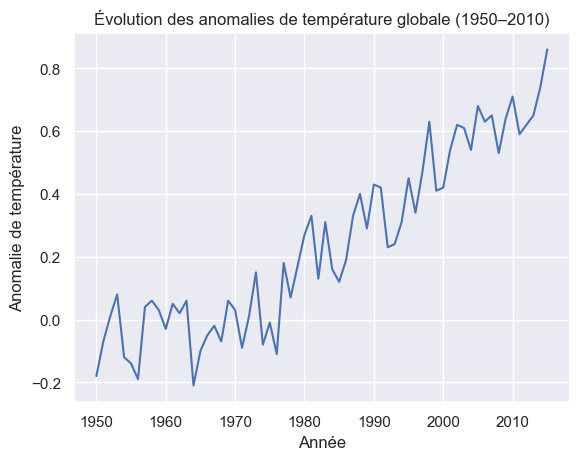

In [85]:
sns.set()
plt.figure()
plt.plot(data['Year'], data['Temp_Anomaly'])
plt.title('Évolution des anomalies de température globale (1950–2010)')
plt.xlabel('Année')
plt.ylabel('Anomalie de température')
plt.show()


# Le graphique montre une tendance nette à la hausse des anomalies de température depuis 1950.
# Malgré des fluctuations à court terme, une augmentation progressive est observée sur le long terme, 
# avec une accélération notable à partir des années 1980.
# Cette évolution indique un réchauffement climatique global continu, en accord avec les observations scientifiques internationales.

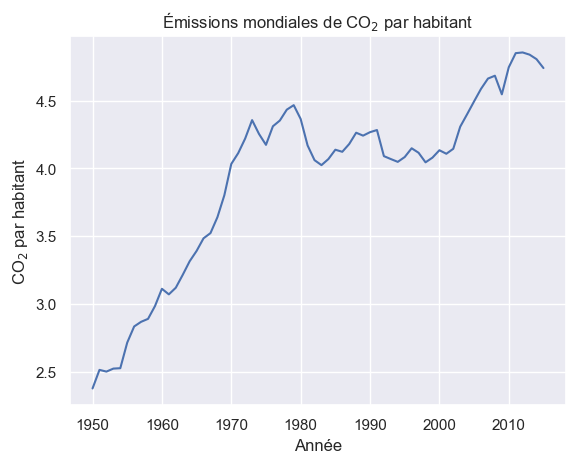

In [86]:
sns.set()
plt.figure()
plt.plot(data['Year'], data['CO2_par_habitant'])
plt.title('Émissions mondiales de CO$_2$ par habitant')
plt.xlabel('Année')
plt.ylabel('CO$_2$ par habitant')
plt.show()



# Ce graphique montre l'évolution des émissions de CO₂ par habitant entre 1950 et 2010.
# Les émissions augmentent de manière constante, passant d'environ 2,4 tonnes par habitant en 1950 à près de 4,7 tonnes en 2010.
# La progression est particulièrement marquée entre 1950 et 1980, où les émissions doublent presque, passant de 2,4 à 4,4 tonnes.
# Après 1980, la croissance ralentit et se stabilise autour de 4,2 à 4,7 tonnes par habitant.
# Cette tendance reflète l'impact de l'industrialisation et de la consommation énergétique mondiale sur les émissions de CO₂.

#### La méthode corr() est utilisée pour calculer la matrice de corrélation entre les variables Temp_Anomaly et CO2_per_capita. Cela permet de mesurer la force et le sens de la relation linéaire entre les émissions de CO₂ et les anomalies de température.

In [87]:
correlation = data[['Temp_Anomaly', 'CO2_par_habitant']].corr()

In [88]:
print(correlation)



# Cette matrice de corrélation montre une forte relation positive (0,72) entre l'anomalie de température et les émissions de CO₂ par habitant.
# Cela signifie que lorsque les émissions de CO₂ augmentent, l'anomalie de température tend également à augmenter.
# Cette corrélation de 0,72 suggère un lien linéaire substantiel entre les deux variables,
# ce qui soutient l'hypothèse que l'augmentation des émissions de CO₂ contribue au réchauffement climatique.

                  Temp_Anomaly  CO2_par_habitant
Temp_Anomaly          1.000000          0.723122
CO2_par_habitant      0.723122          1.000000


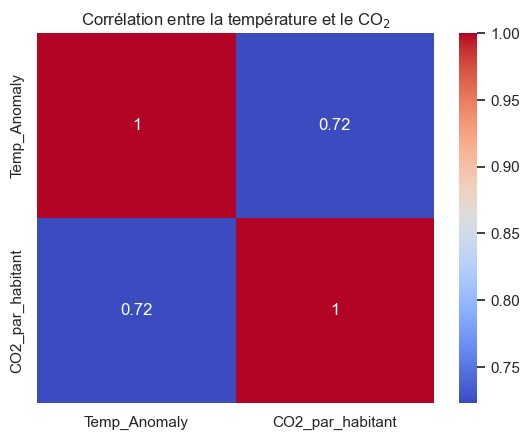

In [89]:
plt.figure()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Corrélation entre la température et le CO$_2$')
plt.show()



#  Cette heatmap montre la matrice de corrélation entre l'anomalie de température et les émissions de CO₂.
#  La valeur de 0,72 indique une forte corrélation positive : quand le CO₂ augmente, la température augmente aussi.
#  La diagonale affiche 1 (corrélation parfaite d'une variable avec elle-même).

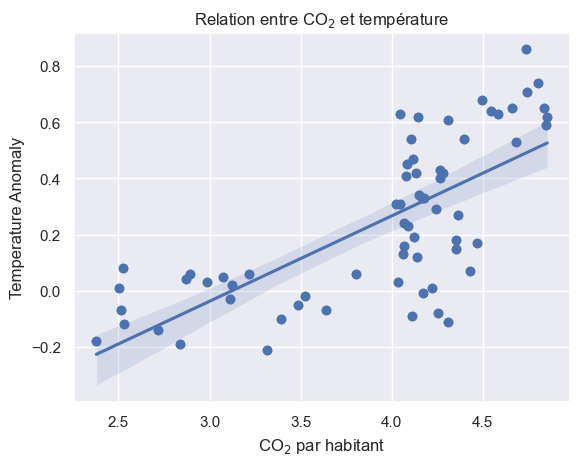

In [90]:
sns.set()
plt.figure()
sns.regplot(x='CO2_par_habitant', y='Temp_Anomaly', data=data)
plt.scatter(data['CO2_par_habitant'], data['Temp_Anomaly'])
plt.title('Relation entre CO$_2$ et température')
plt.xlabel('CO$_2$ par habitant')
plt.ylabel('Temperature Anomaly')
plt.show()



# Ce graphique de dispersion montre la relation entre les émissions de CO₂ par habitant et l'anomalie de température.
# Chaque point représente une année entre 1950 et 2010. La tendance est clairement positive : plus les émissions de CO₂ augmentent, plus la température augmente.
# Cela confirme visuellement la forte corrélation de 0,72 calculée précédemment.


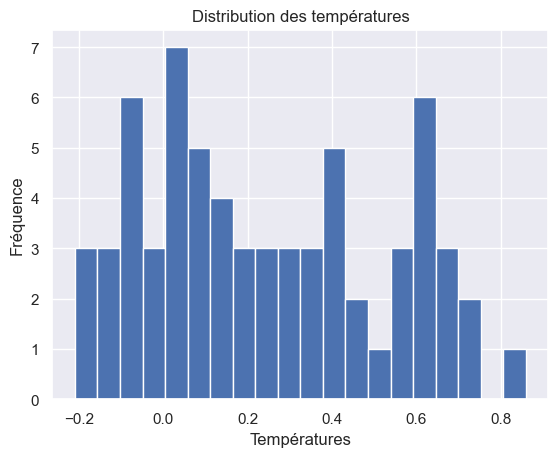

In [91]:
sns.set()
plt.figure()
plt.hist(data['Temp_Anomaly'], bins=20)
plt.title('Distribution des températures')
plt.xlabel('Températures')
plt.ylabel('Fréquence')
plt.show()



# L’histogramme montre que la majorité des valeurs de température est concentrée entre 0 et 0,6.
# Les fréquences les plus élevées se situent dans les intervalles de températures positives modérées.
# Les valeurs extrêmes sont rares, indiquant une dispersion limitée des données.


# Émissions de CO₂ par habitant par pays (1950-2020)

In [92]:
co2.head()

,Entity,Code,Year,CO₂ emissions per capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123


In [93]:
co2.isna().sum()

Entity                      0
Code                        0
Year                        0
CO₂ emissions per capita    0
dtype: int64

#### Ces commandes préparent un jeu de données régional des émissions de CO₂, d'abord en sélectionnant les colonnes 'Entity', 'Year' et 'CO₂ emissions per capita' dans une copie indépendante, puis en filtrant les années à partir de 1950, et enfin en renommant les colonnes 'Entity' en 'Country' et 'CO₂ emissions per capita' en 'CO2_per_capita' pour des noms plus simples.



In [94]:
co2_regional = co2[['Entity', 'Year', 'CO₂ emissions per capita']].copy()
co2_regional = co2_regional[co2_regional['Year'] >= 1950]
co2_regional.rename(columns={'Entity': 'Country', 'CO₂ emissions per capita':'CO2_par_habitant'}, inplace=True)

In [95]:
co2_regional.head()

,Country,Year,CO2_par_habitant
1,Afghanistan,1950,0.010837
2,Afghanistan,1951,0.011625
3,Afghanistan,1952,0.011468
4,Afghanistan,1953,0.013123
5,Afghanistan,1954,0.012945


### Pour plus de simplicité, cinq pays ont été sélectionnés afin d’analyser les émissions de CO₂ par pays 

#### Ces commandes définissent une liste de cinq pays (États-Unis, Chine, Allemagne, Maroc, Nigeria), puis filtrent le DataFrame co2_regional pour ne conserver que les données correspondant à ces pays, le résultat étant stocké dans co2_selected.

In [96]:
countries = ['United States', 'China', 'Germany','Morocco', 'Nigeria']
co2_selected = co2_regional[co2_regional['Country'].isin(countries)]

In [97]:
co2_selected.duplicated().sum()

np.int64(0)

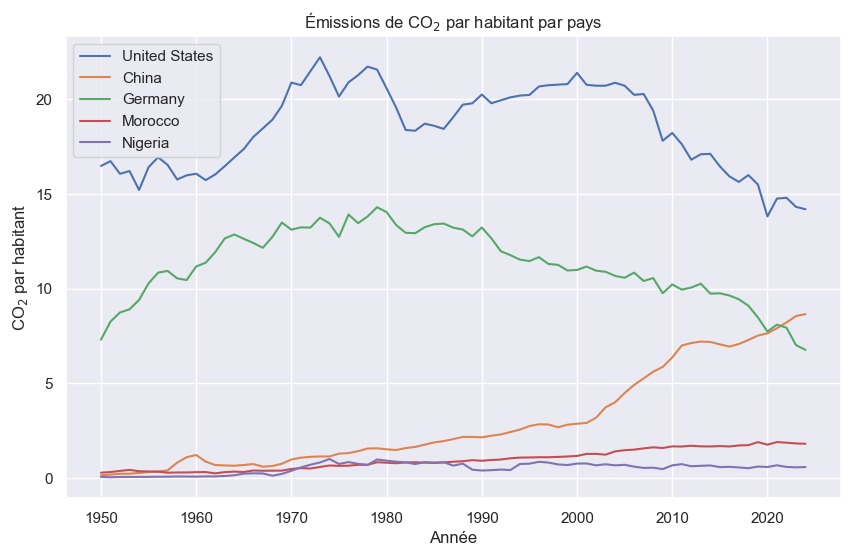

In [98]:
from ipywidgets import Label

plt.figure(figsize=(10,6))
for country in countries:
  subset = co2_selected[co2_selected['Country'] == country]
  plt.plot(subset['Year'], subset['CO2_par_habitant'], label = country)
plt.title('Émissions de CO$_2$ par habitant par pays')
plt.xlabel('Année')
plt.ylabel('CO$_2$ par habitant')
plt.legend()
plt.show()



# Ce tableau montre l'évolution des émissions de CO₂ par habitant de 1950 à 2020 pour cinq pays.
# Les États-Unis ont les émissions les plus élevées, avec un pic vers 1970-1980 (autour de 20 tonnes) avant de diminuer.
# La Chine a connu une augmentation spectaculaire, passant de 0,1 tonne en 1950 à 7,5 tonnes en 2020.
# L'Allemagne a augmenté progressivement jusqu'aux années 1980, puis a diminué légèrement.
# Le Maroc a progressé lentement pour atteindre 1,8 tonne en 2020. Le Nigeria est resté très bas (autour de 0,2 tonne) sur toute la période.
# Ce tableau illustre la divergence entre pays développés et pays en développement, ainsi que l'émergence récente de la Chine comme grand émetteur.